<a href="https://colab.research.google.com/github/25wh1a0536-lgtm/Nasscom/blob/main/week-2/U6_Probability_Statistics_Part1_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)


total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [3]:
print('Mean total_bill:', round(df['total_bill'].mean(), 2))
print('Day value counts:')
print(df['day'].value_counts())


Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [4]:
numerical = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()

print(numerical)
print(categorical)
print(df['tip'].mean())
print(df['sex'].value_counts())


['total_bill', 'tip', 'size']
['sex', 'smoker', 'day', 'time']
2.99827868852459
sex
Male      157
Female     87
Name: count, dtype: int64


Mean   : 19.7859
Median : 17.795
Mode   : 13.42
mean > median ? True -> right-skewed


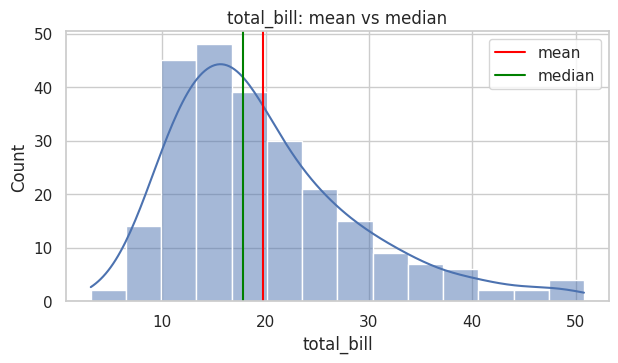

In [5]:
col = df['total_bill']
print('Mean   :', round(col.mean(), 4))
print('Median :', round(col.median(), 4))
print('Mode   :', round(col.mode()[0], 4))

print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()


mean: 3.0
median: 2.9
mode: 2.0
right skewed True ->right skewed


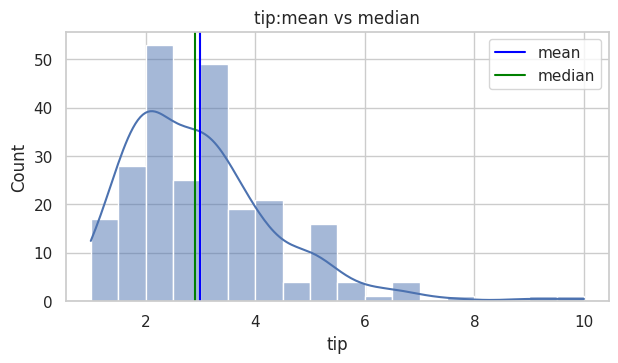

In [6]:
tip = df['tip']
print('mean:',round(tip.mean(),2))
print('median:',round(tip.median(),2))
print('mode:',round(tip.mode()[0],2))
print('right skewed',col.mean()>col.median(),'->right skewed')
plt.figure(figsize=(7,3.5))
sns.histplot(tip,kde=True)
plt.axvline(tip.mean(),color='blue',label='mean')
plt.axvline(tip.median(),color='green',label='median')
plt.legend();plt.title('tip:mean vs median');plt.show()


In [7]:
col = df['total_bill']
print('Range :', round(col.max() - col.min(),4))
print('Var   :', round(col.var(), 2))
print('Std   :', round(col.std(), 2))

q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2))


Range : 47.74
Var   : 79.25
Std   : 8.9
Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78


In [8]:
tip = df['tip']
print('Range :', round(tip.max() - tip.min(),4))
print('Var   :', round(tip.var(), 2))
print('Std   :', round(tip.std(), 2))
q1,q3 = tip.quantile(0.25),tip.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2))


Range : 9.0
Var   : 1.91
Std   : 1.38
Q1 (25%): 2.0
Q3 (75%): 3.56
IQR     : 1.56


min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


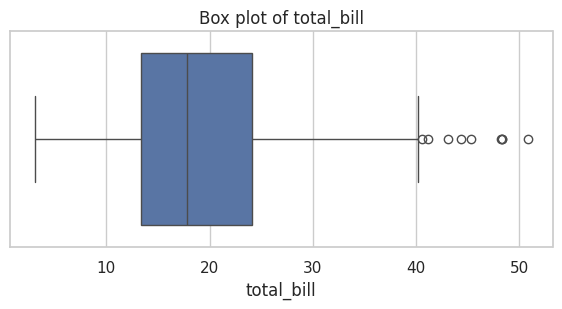

In [9]:
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

print('\nSkewness:', round(col.skew(), 3))

plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()



min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64

Skewness: 1.465


<function matplotlib.pyplot.show(close=None, block=None)>

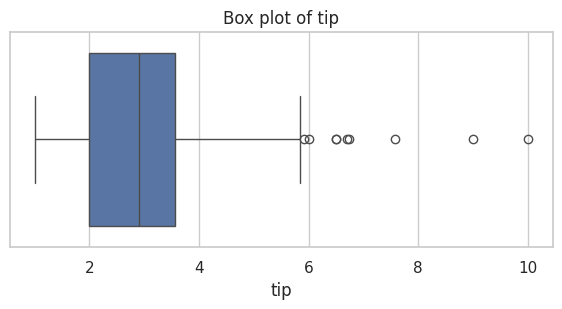

In [10]:
tip = df['tip']
five = tip.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

print('\nSkewness:', round(tip.skew(), 3))
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['tip'])
plt.title('Box plot of tip'); plt.show


            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


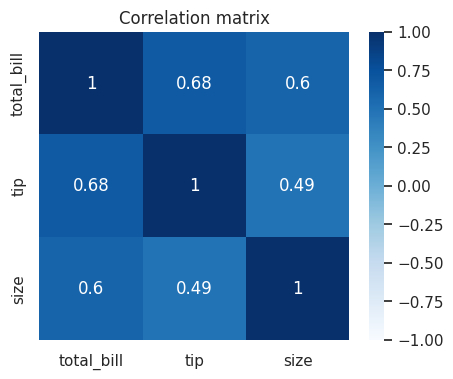

In [11]:
corr = df.corr(numeric_only=True)
print(corr.round(2))

print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()


In [12]:
df.describe()


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


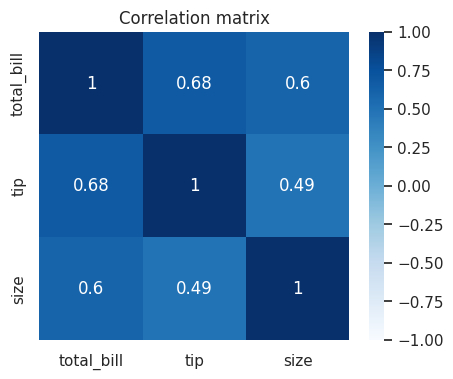

In [13]:
corr = df.corr(numeric_only=True)
print(corr.round(2))
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()
